# Investigating Outlier in Normalized Opening Volatility: 2025-06-16

This notebook investigates the outlier value for normalized opening volatility on 2025-06-16, focusing on 1-minute ATR(14) values at 6:45am and their averages. We will compare this date to its neighbors and visualize the data to understand the anomaly.

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from zoneinfo import ZoneInfo

plt.style.use('seaborn-v0_8-darkgrid')

## Load 1-Minute Bar Data

Load the 1-minute bar CSV file and parse the DateTime column. Convert to America/Los_Angeles timezone if needed.

In [2]:
# 2. Load 1-Minute Bar Data
bars_df = pd.read_csv('MNQ_1min_2023Jan_2026Jan.csv')

# Parse DateTime
bars_df['DateTime'] = pd.to_datetime(bars_df['DateTime'], format='%m/%d/%y %H:%M')

# Convert to America/Los_Angeles timezone (handles DST)
from datetime import timezone
pst = timezone(timedelta(hours=-8))
local_tz = ZoneInfo('America/Los_Angeles')
bars_df['DateTime'] = bars_df['DateTime'].apply(lambda dt: dt.replace(tzinfo=pst).astimezone(local_tz).replace(tzinfo=None))

bars_df['date'] = bars_df['DateTime'].dt.date
bars_df['time'] = bars_df['DateTime'].dt.time

# Filter to 2025 data only for efficiency
bars_df = bars_df[bars_df['DateTime'].dt.year == 2025].copy()

print(f"Loaded {len(bars_df)} 1-minute bars for 2025")
print(f"Date range: {bars_df['DateTime'].min()} to {bars_df['DateTime'].max()}")

Loaded 348585 1-minute bars for 2025
Date range: 2025-01-01 15:00:00 to 2025-12-31 13:59:00


## Calculate ATR(14) for 1-Minute Bars

Compute the True Range and ATR(14) for all 1-minute bars using vectorized pandas operations.

In [3]:
# 3. Calculate ATR(14) for 1-Minute Bars
def calculate_tr(df):
    df = df.copy()
    df['prev_close'] = df['Close'].shift(1)
    hl = df['High'] - df['Low']
    hc = (df['High'] - df['prev_close']).abs()
    lc = (df['Low'] - df['prev_close']).abs()
    df['tr'] = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    return df

def calculate_atr(df, period=14):
    df = calculate_tr(df)
    df['atr'] = df['tr'].ewm(span=period, adjust=False).mean()
    return df

print("Calculating ATR(14) for all bars...")
bars_df = calculate_atr(bars_df.sort_values('DateTime'))
print("ATR calculation complete.")
print(bars_df[['DateTime', 'atr']].head())

Calculating ATR(14) for all bars...
ATR calculation complete.
                  DateTime        atr
685320 2025-01-01 15:00:00  26.250000
685321 2025-01-01 15:01:00  25.250000
685322 2025-01-01 15:02:00  24.816667
685323 2025-01-01 15:03:00  24.041111
685324 2025-01-01 15:04:00  23.868963


## Extract 6:45am ATR Values for All Trading Days

Filter the ATR values at exactly 6:45am for each trading day in 2025. Create a DataFrame with date and ATR.

In [4]:
# 4. Extract 6:45am ATR Values for All Trading Days
ATR_TIME = time(6, 45)
atr_645_df = bars_df[bars_df['time'] == ATR_TIME][['date', 'atr']].copy()
atr_645_df = atr_645_df.sort_values('date').reset_index(drop=True)
print(f"Extracted {len(atr_645_df)} ATR values at 6:45am.")
atr_645_df.head()

Extracted 255 ATR values at 6:45am.


,date,atr
0,2025-01-02,33.819273
1,2025-01-03,22.030055
2,2025-01-06,29.751385
3,2025-01-07,21.901911
4,2025-01-08,29.936093


## Visualize Distribution of 6:45am ATR Values

Plot a histogram and boxplot of the 6:45am ATR values to visually inspect for outliers.

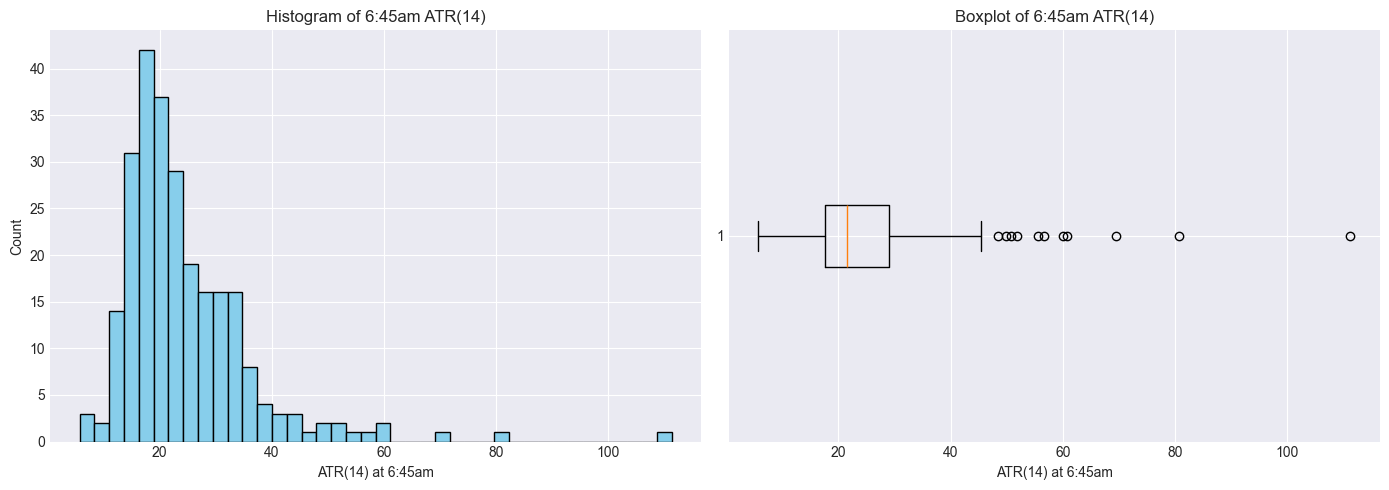

In [5]:
# 5. Visualize Distribution of 6:45am ATR Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(atr_645_df['atr'].dropna(), bins=40, color='skyblue', edgecolor='k')
axes[0].set_title('Histogram of 6:45am ATR(14)')
axes[0].set_xlabel('ATR(14) at 6:45am')
axes[0].set_ylabel('Count')

axes[1].boxplot(atr_645_df['atr'].dropna(), vert=False)
axes[1].set_title('Boxplot of 6:45am ATR(14)')
axes[1].set_xlabel('ATR(14) at 6:45am')

plt.tight_layout()
plt.show()

## Investigate Outlier: 2025-06-16

Print and highlight the ATR value for 2025-06-16. Compare it to the overall distribution and flag if it is an outlier.

In [6]:
# 6. Investigate Outlier: 2025-06-16
outlier_date = pd.to_datetime('2025-06-16').date()
outlier_row = atr_645_df[atr_645_df['date'] == outlier_date]

if not outlier_row.empty:
    outlier_atr = outlier_row.iloc[0]['atr']
    print(f"ATR(14) at 6:45am on 2025-06-16: {outlier_atr:.6f}")
else:
    print("No ATR value found for 2025-06-16 at 6:45am.")

ATR(14) at 6:45am on 2025-06-16: 111.303286


                  DateTime      Open      High       Low     Close  \
844605 2025-06-16 06:30:00  21793.50  21841.50  21593.75  21840.50   
844606 2025-06-16 06:31:00  21840.75  21858.50  21838.75  21856.00   
844607 2025-06-16 06:32:00  21855.75  21861.75  21624.75  21678.50   
844608 2025-06-16 06:38:00  21849.75  21855.50  21848.75  21855.25   
844609 2025-06-16 06:39:00  21855.00  21872.25  21846.25  21865.75   
844610 2025-06-16 06:40:00  21866.00  21872.75  21628.25  21859.75   
844611 2025-06-16 06:41:00  21860.00  21868.75  21850.00  21861.00   
844612 2025-06-16 06:42:00  21860.50  21865.25  21612.00  21856.50   
844613 2025-06-16 06:43:00  21856.50  21864.25  21846.00  21863.75   
844614 2025-06-16 06:44:00  21863.50  21872.25  21615.50  21861.25   
844615 2025-06-16 06:45:00  21862.50  21886.75  21862.00  21878.00   
844616 2025-06-16 06:46:00  21878.50  21880.00  21674.25  21865.25   
844617 2025-06-16 06:47:00  21864.75  21870.25  21839.50  21843.50   
844618 2025-06-16 06

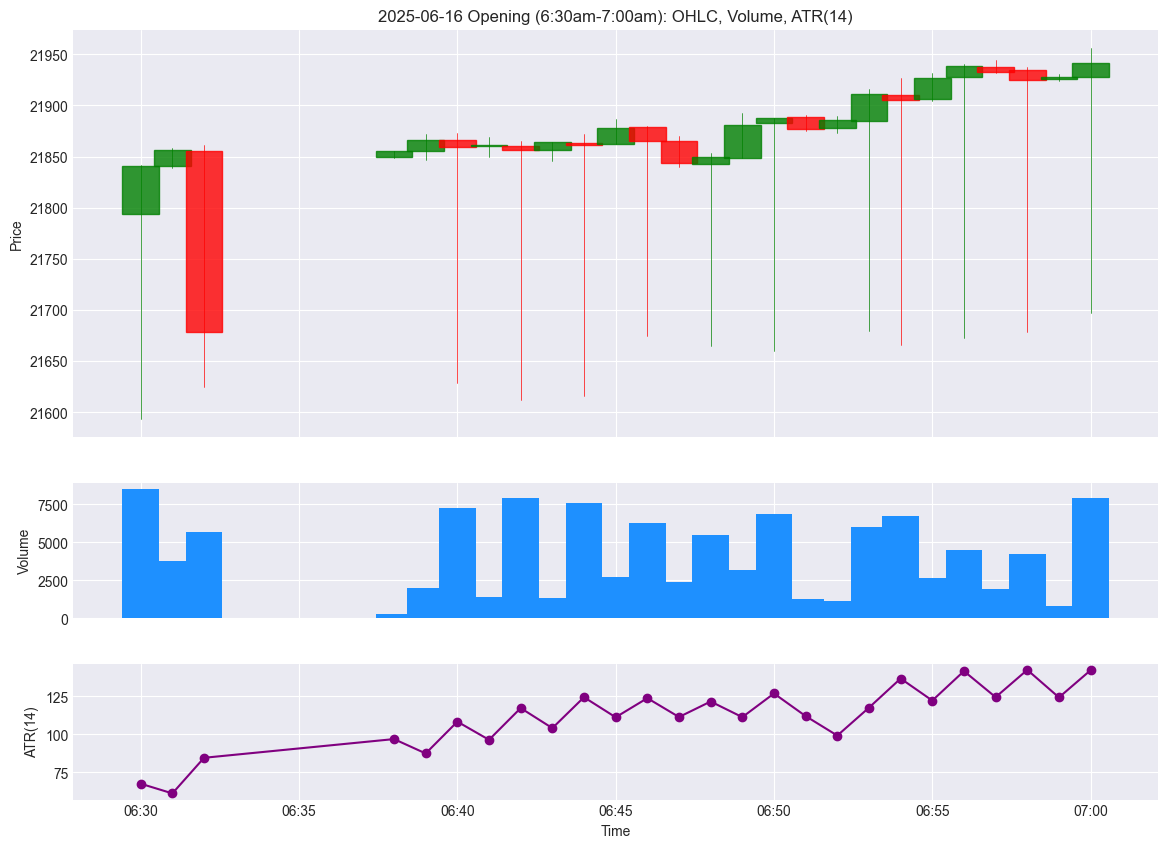

In [7]:
from mplfinance.original_flavor import candlestick_ohlc

# Plot OHLCV (candlestick), volume, and ATR(14) for the opening (6:30am-7:00am) for 2025-06-16

import matplotlib.dates as mdates
start_time = time(6, 30)
end_time = time(7, 0)

# Filter bars for 2025-06-16, 6:30am-7:00am
open_bars = bars_df[(bars_df['date'] == outlier_date) &
                    (bars_df['DateTime'].dt.time >= start_time) &
                    (bars_df['DateTime'].dt.time <= end_time)].copy()

print(open_bars.head(20))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True, 
                                    gridspec_kw={'height_ratios': [3, 1, 1]})

# Candlestick chart

ohlc = open_bars[['DateTime', 'Open', 'High', 'Low', 'Close']].copy()
ohlc['DateTime'] = mdates.date2num(ohlc['DateTime'])
candlestick_ohlc(ax1, ohlc.values, width=0.0008, colorup='g', colordown='r', alpha=0.8)
ax1.set_ylabel('Price')
ax1.set_title(f'2025-06-16 Opening (6:30am-7:00am): OHLC, Volume, ATR(14)')

# Volume bar plot
ax2.bar(open_bars['DateTime'], open_bars['Volume(from bar)'], width=0.0008, color='dodgerblue')
ax2.set_ylabel('Volume')

# ATR(14) line plot
ax3.plot(open_bars['DateTime'], open_bars['atr'], color='purple', marker='o')
ax3.set_ylabel('ATR(14)')
ax3.set_xlabel('Time')

# Format x-axis as time
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.tight_layout()
#plt.show()

## Compare 2025-06-16 to Previous 5 Trading Days

Extract and display the 6:45am ATR values for the 5 trading days before 2025-06-16. Compute their mean and compare to the outlier.

In [8]:
# 7. Compare 2025-06-16 to Previous 5 Trading Days
idx = atr_645_df[atr_645_df['date'] == outlier_date].index
if len(idx) > 0 and idx[0] >= 5:
    prev5 = atr_645_df.iloc[idx[0]-5:idx[0]]
    print("Previous 5 trading days (6:45am ATR):")
    print(prev5)
    mean_prev5 = prev5['atr'].mean()
    std_prev5 = prev5['atr'].std()
    print(f"Mean ATR(14) at 6:45am (prev 5 days): {mean_prev5:.6f}")
    print(f"Std ATR(14) at 6:45am (prev 5 days): {std_prev5:.6f}")
    print(f"Outlier / Mean: {outlier_atr / mean_prev5 if mean_prev5 else np.nan:.2f}")
else:
    print("Not enough previous days to compare.")

Previous 5 trading days (6:45am ATR):
           date        atr
110  2025-06-09  17.927172
111  2025-06-10  19.037115
112  2025-06-11  17.821526
113  2025-06-12  17.555644
114  2025-06-13  22.092913
Mean ATR(14) at 6:45am (prev 5 days): 18.886874
Std ATR(14) at 6:45am (prev 5 days): 1.879457
Outlier / Mean: 5.89


## Visualize ATR Time Series Around 2025-06-16

Plot the ATR(14) time series for 6:30am to 7:00am for 2025-06-16 and its neighboring days to see if the spike is isolated or part of a trend.

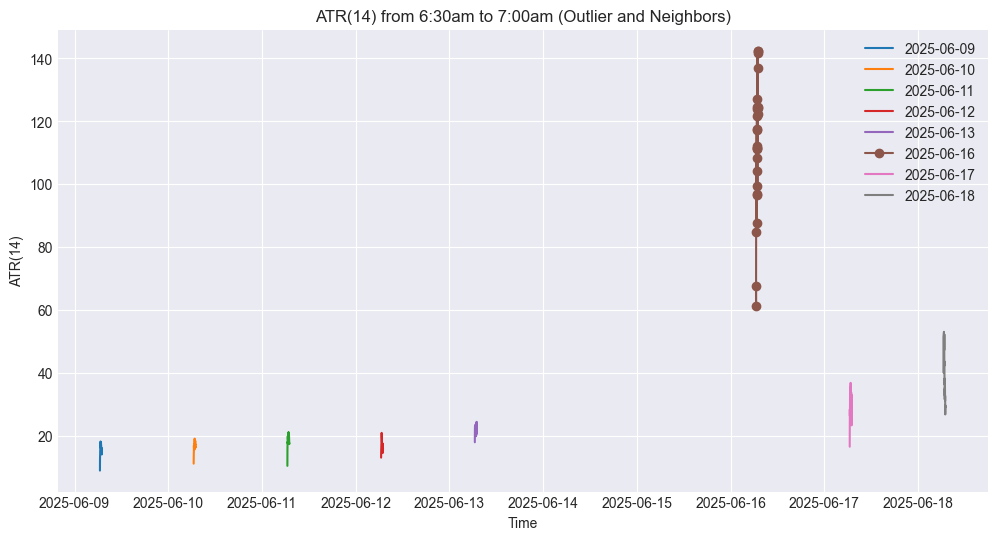

In [9]:
# 8. Visualize ATR Time Series Around 2025-06-16
# Get dates: previous 5, outlier, next 2
dates_to_plot = []
if len(idx) > 0:
    start = max(0, idx[0]-5)
    end = min(len(atr_645_df), idx[0]+3)
    dates_to_plot = atr_645_df.iloc[start:end]['date'].tolist()

# Filter bars for these dates and times
start_time = time(6, 30)
end_time = time(7, 0)
plot_bars = bars_df[(bars_df['date'].isin(dates_to_plot)) &
                    (bars_df['time'] >= start_time) & (bars_df['time'] <= end_time)]

fig, ax = plt.subplots(figsize=(12, 6))
for d in dates_to_plot:
    day_bars = plot_bars[plot_bars['date'] == d]
    ax.plot(day_bars['DateTime'], day_bars['atr'], label=str(d), marker='o' if d == outlier_date else None)
ax.set_title('ATR(14) from 6:30am to 7:00am (Outlier and Neighbors)')
ax.set_xlabel('Time')
ax.set_ylabel('ATR(14)')
ax.legend()
plt.show()

## Summary Table of ATR Values for Outlier and Neighbors

Create a summary table showing the ATR(14) at 6:45am for 2025-06-16 and the previous 5 trading days, including their mean and standard deviation.

In [10]:
# 9. Summary Table of ATR Values for Outlier and Neighbors
summary_dates = dates_to_plot if dates_to_plot else []
summary_df = atr_645_df[atr_645_df['date'].isin(summary_dates)].copy()
summary_df = summary_df.set_index('date')
summary_df['is_outlier'] = summary_df.index == outlier_date
summary_df['mean_prev5'] = np.nan
summary_df['std_prev5'] = np.nan
for i, d in enumerate(summary_df.index):
    idx = atr_645_df[atr_645_df['date'] == d].index
    if len(idx) > 0 and idx[0] >= 5:
        prev5 = atr_645_df.iloc[idx[0]-5:idx[0]]
        summary_df.at[d, 'mean_prev5'] = prev5['atr'].mean()
        summary_df.at[d, 'std_prev5'] = prev5['atr'].std()

print("Summary Table (ATR at 6:45am):")
display(summary_df[['atr', 'is_outlier', 'mean_prev5', 'std_prev5']])

Summary Table (ATR at 6:45am):


,atr,is_outlier,mean_prev5,std_prev5
date,,,,
2025-06-09,17.927172,False,20.970488,4.326077
2025-06-10,19.037115,False,20.344006,4.531866
2025-06-11,17.821526,False,20.240785,4.560169
2025-06-12,17.555644,False,20.331200,4.492993
2025-06-13,22.092913,False,18.178302,0.602872
2025-06-16,111.303286,True,18.886874,1.879457
2025-06-17,34.983403,False,37.562097,41.261913
2025-06-18,43.590411,False,40.751355,40.071186
